In [137]:
import numpy as np
import sympy
from matplotlib import pyplot as plt

In [138]:
print("hello")

hello


<div align="center">
  <h3>Этап 1</h3>
</div>

Система для поиска стационарных решений 

$ k_1z - k_{-1}x - k_2z ^ 2x = 0 $ \
$ k_3z - k_{-3}y = 0 $


In [ ]:
z, x, y, k1, km1, k2, k3, km3 = sympy.symbols('z x y k1 km1 k2 k3 km3') 
z = 1 - x - y

f1 = k1 * z - km1 * x - k2 * z * z * x # выражежние 1
f2 = k3 * z - km3 * y # выражение 2

eq1 = sympy.Eq(f1, 0) # уравнение 1
eq2 = sympy.Eq(f2, 0) # уравнение 2

In [ ]:
A = sympy.Matrix([f1, f2])
var_vector = sympy.Matrix([x, y])
jacA = A.jacobian(var_vector) 
det_jacA = jacA.det()
trace_jacA = jacA.trace()
DI = trace_jacA ** 2 - 4 * det_jacA

Выпишем как выглядит якобиан, его след и определитель 

In [134]:
print("Якобиан")
jacA

Якобиан


Matrix([
[-k1 - k2*x*(2*x + 2*y - 2) - k2*(-x - y + 1)**2 - km1, -k1 - k2*x*(2*x + 2*y - 2)],
[                                                  -k3,                  -k3 - km3]])

In [132]:
print("След")
trace_jacA

След


-k1 - k2*x*(2*x + 2*y - 2) - k2*(-x - y + 1)**2 - k3 - km1 - km3

In [135]:
print("Определитель")
det_jacA

Определитель


k1*km3 + k2*k3*x**2 + 2*k2*k3*x*y - 2*k2*k3*x + k2*k3*y**2 - 2*k2*k3*y + k2*k3 + 3*k2*km3*x**2 + 4*k2*km3*x*y - 4*k2*km3*x + k2*km3*y**2 - 2*k2*km3*y + k2*km3 + k3*km1 + km1*km3


<div align="center">
  <h3>Этап 2</h3>
</div>


<div align="center">
  <h3>Однопараметрический анализ 1</h3>
</div>

In [141]:
x_list = np.linspace(1, 987, 987) / 1000 # сетка по значениям x
km1_list = [0.001, 0.005, 0.01, 0.015, 0.02] # перебор параметров, требуемых в задании

<div align="center">
  <h3>Зависимость от k1</h3>
</div>

In [142]:
k1_x, y_x  = sympy.solve([eq1, eq2], k1, y)[0] # выразим k1 и y через переменную x

In [ ]:
for val in km1_list:
    # Ввод значений заданных параметров в символьные выражения
    t_k1_x = k1_x.subs({k2: 2, km3: 0.003, k3: 0.0032, km1: val})
    t_y_x = y_x.subs({k2: 2, km3: 0.003, k3: 0.0032, km1: val})
    deter = det_jacA.subs({k2: 2, km3: 0.003, k3: 0.0032, km1: val})
    trace = trace_jacA.subs({k2: 2, km3: 0.003, k3: 0.0032, km1: val})
    har_det = DI.subs({k2: 2, km3: 0.003, k3: 0.0032, km1: val})

    # Определение лямбда функций для символьных выражений
    ft_k1_x = sympy.lambdify(x, t_k1_x, 'numpy')
    ft_y_x = sympy.lambdify(x, t_y_x, 'numpy')
    f_deter = sympy.lambdify([x, y, k1], deter, 'numpy')
    f_trace = sympy.lambdify([x, y, k1], trace, 'numpy')
    f_har_det = sympy.lambdify([x, y, k1], har_det, 'numpy')

    # Расчет значений выражений на всей сетке x_list
    y_list = ft_y_x(x_list)
    k1_list = ft_k1_x(x_list)
    deter_list = f_deter(x_list, y_list, k1_list)
    trace_list = f_trace(x_list, y_list, k1_list)
    har_det_list = f_har_det(x_list, y_list, k1_list)

    # определение седловых узлов через поиск нуля определителя
    p = deter_list[:-1] * deter_list[1:] 
    x_sn = x_list[1:][p < 0]
    y_sn = y_list[1:][p < 0]
    k1_sn = k1_list[1:][p < 0]

    # определение точек хопфа через поиск нуля следа
    p = trace_list[:-1] * trace_list[1:] 
    x_h = x_list[1:][p < 0]
    y_h = y_list[1:][p < 0]
    k1_h = k1_list[1:][p < 0]

    

    plt.figure()
    plt.scatter(k1_h, x_h, label='hopf', marker='*', color='r')
    plt.scatter(k1_h, y_h, label='hopf', marker='*', color='r')

    plt.scatter(k1_sn, x_sn, label='sn', color='b')
    plt.scatter(k1_sn, y_sn, label='sn', color='b')
    plt.plot(k1_list, x_list, label='x')
    plt.plot(k1_list, y_list, label='y')
    plt.xlabel('k1')
    plt.ylabel('x, y')
    plt.xlim(0, 0.35)
    plt.ylim(0, 1)
    plt.legend()
    plt.title(f"km1 = {val}")
    plt.show()    

<div align="center">
  <h3>Зависимость от k2</h3>
</div>

In [ ]:
k2_x, y_x  = sympy.solve([eq1, eq2], k2, y)[0] # выразим k2 и y через x

In [ ]:
for val in km1_list:
    # Ввод значений заданных параметров в символьные выражения
    t_k2_x = k2_x.subs({k1: 0.3, km3: 0.003, k3: 0.0032, km1: val})
    t_y_x = y_x.subs({k1: 0.3, km3: 0.003, k3: 0.0032, km1: val})
    deter = det_jacA.subs({k1: 0.3, km3: 0.003, k3: 0.0032, km1: val})
    trace = trace_jacA.subs({k1: 0.3, km3: 0.003, k3: 0.0032, km1: val})
    har_det = DI.subs({k1: 0.3, km3: 0.003, k3: 0.0032, km1: val})

    # Определение лямбда функций для символьных выражений
    ft_k2_x = sympy.lambdify(x, t_k2_x, 'numpy')
    ft_y_x = sympy.lambdify(x, t_y_x, 'numpy')
    f_deter = sympy.lambdify([x, y, k2], deter, 'numpy')
    f_trace = sympy.lambdify([x, y, k2], trace, 'numpy')
    f_har_det = sympy.lambdify([x, y, k2], har_det, 'numpy')

    # Расчет значений выражений на всей сетке x_list
    y_list = ft_y_x(x_list)
    k2_list = ft_k2_x(x_list)
    deter_list = f_deter(x_list, y_list, k2_list)
    trace_list = f_trace(x_list, y_list, k2_list)
    har_det_list = f_har_det(x_list, y_list, k2_list)

    # определение седловых узлов через поиск нуля определителя
    p = deter_list[:-1] * deter_list[1:]
    x_sn = x_list[1:][p < 0]
    y_sn = y_list[1:][p < 0]
    k2_sn = k2_list[1:][p < 0]

    # определение точек хопфа через поиск нуля следа
    p = trace_list[:-1] * trace_list[1:]
    x_h = x_list[1:][p < 0]
    y_h = y_list[1:][p < 0]
    k2_h = k2_list[1:][p < 0]


    plt.figure()
    plt.scatter(k2_h, x_h, label='hopf', color='r')
    plt.scatter(k2_h, y_h, label='hopf', color='r')

    plt.scatter(k2_sn, x_sn, label='sn', color='b')
    plt.scatter(k2_sn, y_sn, label='sn', color='b')
    plt.plot(k2_list, x_list, label='x')
    plt.plot(k2_list, y_list, label='y')
    plt.xlabel('k2')
    plt.ylabel('x, y')
    plt.xlim(-10, 30)
    plt.ylim(0, 1)
    plt.legend()
    plt.title(f"km1 = {val}")
    plt.show()    


<div align="center">
  <h3>Однопараметрический анализ 2</h3>
</div>

In [ ]:
km3_list = [0.0005, 0.001, 0.002, 0.003, 0.004] # Список значений параметра, требуемого в задании

<div align="center">
  <h3>Зависимость от k1</h3>
</div>

In [ ]:
for val in km3_list:
    # Ввод значений заданных параметров в символьные выражения
    t_k1_x = k1_x.subs({k2: 2, km3: val, k3: 0.0032, km1: 0.03})
    t_y_x = y_x.subs({k2: 2, km3: val, k3: 0.0032, km1: 0.03})
    deter = det_jacA.subs({k2: 2, km3: val, k3: 0.0032, km1: 0.03})
    trace = trace_jacA.subs({k2: 2, km3: val, k3: 0.0032, km1: 0.03})
    har_det = DI.subs({k2: 2, km3: val, k3: 0.0032, km1: 0.03})

    # Определение лямбда функций для символьных выражений
    ft_k1_x = sympy.lambdify(x, t_k1_x, 'numpy')
    ft_y_x = sympy.lambdify(x, t_y_x, 'numpy')
    f_deter = sympy.lambdify([x, y, k1], deter, 'numpy')
    f_trace = sympy.lambdify([x, y, k1], trace, 'numpy')
    f_har_det = sympy.lambdify([x, y, k1], har_det, 'numpy')

    # Расчет значений выражений на всей сетке x_list
    y_list = ft_y_x(x_list)
    k1_list = ft_k1_x(x_list)
    deter_list = f_deter(x_list, y_list, k1_list)
    trace_list = f_trace(x_list, y_list, k1_list)
    har_det_list = f_har_det(x_list, y_list, k1_list)

    # определение седловых узлов через поиск нуля определителя
    p = deter_list[:-1] * deter_list[1:]
    x_sn = x_list[1:][p < 0]
    y_sn = y_list[1:][p < 0]
    k1_sn = k1_list[1:][p < 0]

    # определение точек хопфа через поиск нуля следа
    p = trace_list[:-1] * trace_list[1:]
    x_h = x_list[1:][p < 0]
    y_h = y_list[1:][p < 0]
    k1_h = k1_list[1:][p < 0]


    plt.figure()
    plt.scatter(k1_h, x_h, label='hopf', color='r')
    plt.scatter(k1_h, y_h, label='hopf', color='r')

    plt.scatter(k1_sn, x_sn, label='sn', color='b')
    plt.scatter(k1_sn, y_sn, label='sn', color='b')
    plt.plot(k1_list, x_list, label='x')
    plt.plot(k1_list, y_list, label='y')
    plt.xlabel('k1')
    plt.ylabel('x, y')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.legend()
    plt.title(f"km3 = {val}")
    plt.show()    


    

<div align="center">
  <h3>Зависимость от k2</h3>
</div>

In [ ]:
for val in km3_list:
    # Ввод значений заданных параметров в символьные выражения
    t_k2_x = k2_x.subs({k1: 0.3, km3: val, k3: 0.0032, km1: 0.03})
    t_y_x = y_x.subs({k1: 0.3, km3: val, k3: 0.0032, km1: 0.03})
    deter = det_jacA.subs({k1: 0.3, km3: val, k3: 0.0032, km1: 0.03})
    trace = trace_jacA.subs({k1: 0.3, km3: val, k3: 0.0032, km1: 0.03})
    har_det = DI.subs({k1: 0.3, km3: val, k3: 0.0032, km1: 0.03})

    # Определение лямбда функций для символьных выражений
    ft_k2_x = sympy.lambdify(x, t_k2_x, 'numpy')
    ft_y_x = sympy.lambdify(x, t_y_x, 'numpy')
    f_deter = sympy.lambdify([x, y, k2], deter, 'numpy')
    f_trace = sympy.lambdify([x, y, k2], trace, 'numpy')
    f_har_det = sympy.lambdify([x, y, k2], har_det, 'numpy')

    # Расчет значений выражений на всей сетке x_list
    y_list = ft_y_x(x_list)
    k2_list = ft_k2_x(x_list)
    deter_list = f_deter(x_list, y_list, k2_list)
    trace_list = f_trace(x_list, y_list, k2_list)
    har_det_list = f_har_det(x_list, y_list, k2_list)

    # определение седловых узлов через поиск нуля определителя
    p = deter_list[:-1] * deter_list[1:]
    x_sn = x_list[1:][p < 0]
    y_sn = y_list[1:][p < 0]
    k2_sn = k2_list[1:][p < 0]

    # определение точек хопфа через поиск нуля следа
    p = trace_list[:-1] * trace_list[1:]
    x_h = x_list[1:][p < 0]
    y_h = y_list[1:][p < 0]
    k2_h = k2_list[1:][p < 0]

    plt.figure()
    plt.scatter(k2_h, x_h, label='hopf', color='r')
    plt.scatter(k2_h, y_h, label='hopf', color='r')

    plt.scatter(k2_sn, x_sn, label='sn', color='b')
    plt.scatter(k2_sn, y_sn, label='sn', color='b')
    plt.plot(k2_list, x_list, label='x')
    plt.plot(k2_list, y_list, label='y')
    plt.xlabel('k2')
    plt.ylabel('x, y')
    plt.xlim(0, 30)
    plt.ylim(0, 1)
    plt.legend()
    plt.title(f"km1 = {val}")
    plt.show()    

<div align="center">
  <h3>Этап 3</h3>
</div>

<div align="center">
  <h3>Двухпараметрический анализ (k1, k2)</h3>
</div>

In [ ]:
eq_trace = sympy.Eq(trace_jacA, 0) # уравнение след = 0
eq_det = sympy.Eq(det_jacA, 0) # уравнение определитель = 0

In [ ]:
#добавим в иходную систему необходимые соотношения для поиска линий нейтральности и гладкости
k1_x, k2_x, y_x = sympy.solve([eq1, eq2, eq_trace], k1, k2, y)[0] # линий нейтральности
k1_x_det, k2_x_det, y_x_det = sympy.solve([eq1, eq2, eq_det], k1, k2, y)[0] # линия кратности


In [ ]:
# вставка параметров в найденые соотношения
t_k1_x = k1_x.subs({km3: 0.003, km1: 0.03, k3: 0.0032})
t_k2_x = k2_x.subs({km3: 0.003, km1: 0.03, k3: 0.0032})
t_k1_x_det = k1_x_det.subs({km3: 0.003, km1: 0.03, k3: 0.0032})
t_k2_x_det = k2_x_det.subs({km3: 0.003, km1: 0.03, k3: 0.0032})

In [ ]:
# составление лямбда функций с аргументом x
ft_k1_x = sympy.lambdify(x, t_k1_x, 'numpy')
ft_k2_x = sympy.lambdify(x, t_k2_x, 'numpy')

ft_k1_x_det = sympy.lambdify(x, t_k1_x_det, 'numpy')
ft_k2_x_det = sympy.lambdify(x, t_k2_x_det, 'numpy')


Text(0, 0.5, 'k2')

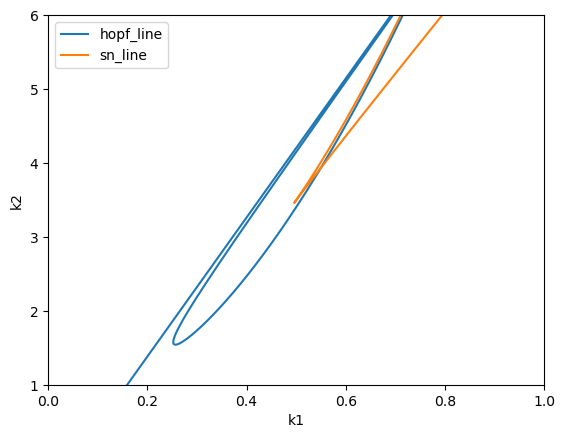

In [126]:
plt.plot(ft_k1_x(x_list), ft_k2_x(x_list), label = 'hopf_line')
plt.plot(ft_k1_x_det(x_list), ft_k2_x_det(x_list), label = 'sn_line')
plt.xlim(0, 1)
plt.ylim(1, 6)
plt.legend()
plt.xlabel('k1')
plt.ylabel('k2')